## Wine Classification using KNN

### Project Overview
This notebook demonstrates an end-to-end K-Nearest Neighbors (KNN) classification workflow on the Wine dataset — predicting which of 3 wine classes a sample belongs to, based on 13 chemical properties.

### Workflow
1. Import required libraries
2. Load and validate the dataset
3. Explore the target variable (check number of classes, class balance)
4. Split features and target (X, y)
5. Train-test split (with stratification)
6. Standardize numerical features (critical for KNN — distance-based algorithm)
7. Train a KNN model with an initial choice of K
8. Generate predictions on the test set
9. Evaluate performance (accuracy, confusion matrix, classification report)
10. Tune K (try multiple values, compare accuracy — find optimal K)
11. Compare KNN performance against the earlier Logistic Regression baseline (Iris/Titanic)

# 1. Import required libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tawfikelmetwally/wine-dataset/Wine dataset.csv


In [27]:
import matplotlib.pyplot as plt

# 2. Load and validate the dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/tawfikelmetwally/wine-dataset/Wine dataset.csv')
df.head()

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [4]:
df.isna().sum()

class                           0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
class,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity of ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


# 3. Explore the target variable (check number of classes, class balance)

In [6]:
print(df['class'].nunique())
print(df['class'].value_counts())

3
class
2    71
1    59
3    48
Name: count, dtype: int64


In [7]:
df.groupby('class').mean()

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
class,,,,,,,,,,,,,
1,13.744746,2.010678,2.455593,17.037288,106.338983,2.840169,2.982373,0.290000,1.899322,5.528305,1.062034,3.157797,1115.711864
2,12.278732,1.932676,2.244789,20.238028,94.549296,2.258873,2.080845,0.363662,1.630282,3.086620,1.056282,2.785352,519.507042
3,13.153750,3.333750,2.437083,21.416667,99.312500,1.678750,0.781458,0.447500,1.153542,7.396250,0.682708,1.683542,629.895833


**Strong separators (large differences across classes):**
- `Flavanoids` — Class 1: 2.98, Class 2: 2.08, Class 3: 0.78
- `Proline` — Class 1: 1115, Class 2: 519, Class 3: 630
- `Color intensity` — Class 1: 5.5, Class 2: 3.1, Class 3: 7.4

**Weak separators (similar averages across classes):**
- `Ash` — all classes cluster around 2.2–2.5
- `Hue` — Class 1 and Class 2 nearly identical (~1.06)

**Decision:** Kept all 13 features for this round rather than dropping weak ones — after scaling, weak features naturally contribute less "vote" to distance calculations anyway. Noted `Flavanoids`/`Proline` as strong candidate features for future feature-selection experiments.

In [23]:
df.columns.tolist()

['class',
 'Alcohol',
 'Malic acid',
 'Ash',
 'Alcalinity of ash',
 'Magnesium',
 'Total phenols',
 'Flavanoids',
 'Nonflavanoid phenols',
 'Proanthocyanins',
 'Color intensity',
 'Hue',
 'OD280/OD315 of diluted wines',
 'Proline ']

<Axes: xlabel='Flavanoids', ylabel='Proline '>

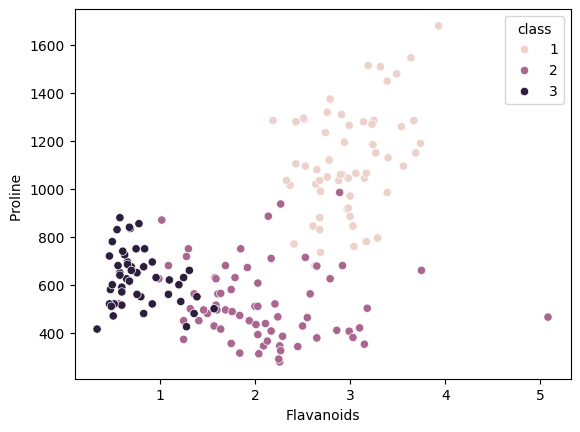

In [24]:
import seaborn as sns
sns.scatterplot(data=df, x='Flavanoids', y='Proline ', hue='class')

<Axes: >

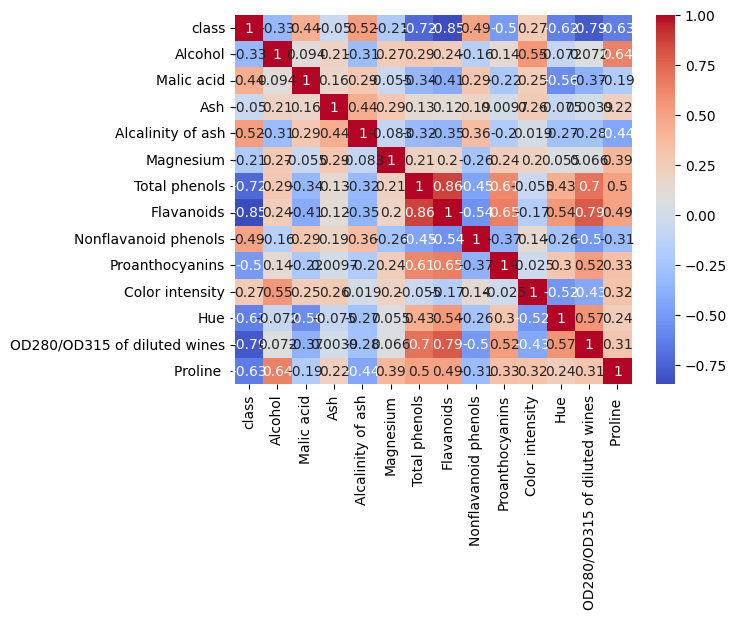

In [25]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# 4. Split features and target (X, y)

In [8]:
X = df.drop(columns=['class'])
y = df['class']

# 5. Train-test split (with stratification)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2, random_state=42, stratify = y)

print(X_train.shape, X_test.shape)

(142, 13) (36, 13)


# 6. Standardize numerical features (critical for KNN — distance-based algorithm)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data:\n", X_train_scaled.shape)
print("Scaled Testing Data:\n", X_test_scaled.shape)

Scaled Training Data:
 (142, 13)
Scaled Testing Data:
 (36, 13)


# 7. Train a KNN model with an initial choice of K

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

# 8. Generate predictions on the test set

In [14]:
y_pred = knn.predict(X_test_scaled)
y_pred

array([1, 3, 1, 2, 2, 1, 1, 2, 2, 3, 2, 3, 1, 3, 1, 2, 2, 1, 2, 1, 2, 2,
       1, 1, 2, 2, 1, 3, 3, 3, 1, 3, 2, 3, 3, 3])

# 9. Evaluate performance (accuracy, confusion matrix, classification report)

Accuracy Score: 0.97

Classification Report:
              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00        12
     Class 2       1.00      0.93      0.96        14
     Class 3       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]


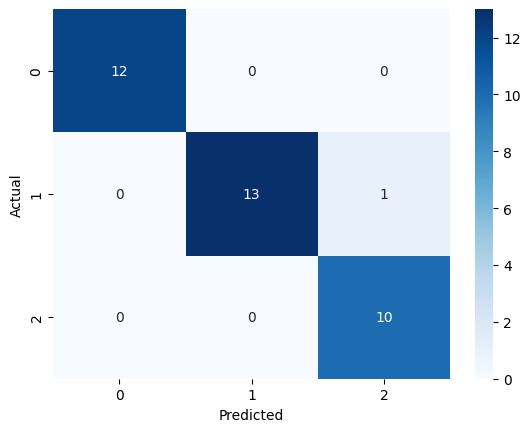

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate overall accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc:.2f}\n")

# 2. Generate a text-based classification report
report = classification_report(y_test, y_pred, target_names = ['Class 1', 'Class 2', 'Class 3'])
print("Classification Report:")
print(report)

# 3. Compute the raw confusion matrix
matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(matrix)

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 10. Tune K (try multiple values, compare accuracy — find optimal K)

In [17]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())
    print(k , scores.mean())

1 0.9366995073891626
2 0.9369458128078818
3 0.9440886699507389
4 0.9438423645320198
5 0.9509852216748769
6 0.951231527093596
7 0.9578817733990148
8 0.958128078817734
9 0.9507389162561577
10 0.9578817733990148
11 0.97192118226601
12 0.97192118226601
13 0.97192118226601
14 0.9578817733990148
15 0.9650246305418719
16 0.9721674876847292
17 0.9650246305418719
18 0.9790640394088669
19 0.97192118226601
20 0.97192118226601


In [32]:
import numpy as np

best_score = max(cv_scores)
threshold = best_score - 0.01  # 1% tolerance

for k, score in zip(k_values, cv_scores):
    if score >= threshold:
        best_k = k
        break

print(f"Best K (smallest K within 1% of peak): {best_k}")

Best K (smallest K within 1% of peak): 11


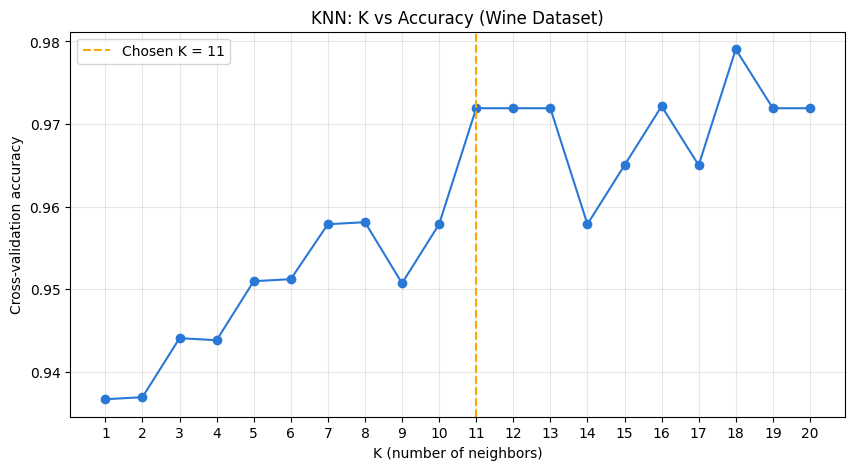

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(list(k_values), cv_scores, marker='o', color='#2a78d6')
plt.axvline(x=best_k, color='orange', linestyle='--', label='Chosen K = 11')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Cross-validation accuracy')
plt.title('KNN: K vs Accuracy (Wine Dataset)')
plt.xticks(list(k_values))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
final_accuracy = final_knn.score(X_test_scaled, y_test)
print(f"Final Test Accuracy with K={best_k}: {final_accuracy}")

Final Test Accuracy with K=11: 1.0


# 11. Compare KNN performance against the earlier Logistic Regression baseline (Iris/Titanic)

Accuracy Score: 0.97

Classification Report:
              precision    recall  f1-score   support

     Class 1       1.00      1.00      1.00        12
     Class 2       0.93      1.00      0.97        14
     Class 3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


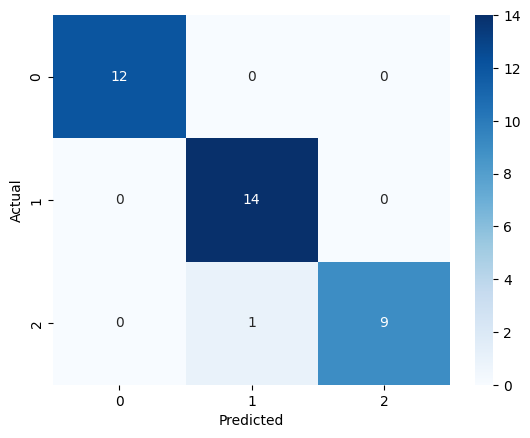

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred_log = model.predict(X_test_scaled)

# 1. Calculate overall accuracy
acc = accuracy_score(y_test, y_pred_log)
print(f"Accuracy Score: {acc:.2f}\n")

# 2. Generate a text-based classification report
report = classification_report(y_test, y_pred_log, target_names = ['Class 1', 'Class 2', 'Class 3'])
print("Classification Report:")
print(report)

# 3. Compute the raw confusion matrix
matrix = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:")
print(matrix)

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## KNN vs Logistic Regression — Wine Dataset Comparison

| Model | Accuracy | Errors (of 36) |
|---|---|---|
| Logistic Regression | 97% | 1 |
| KNN (K=5, default) | 97% | 1 |
| KNN (K=11, tuned via 5-fold CV) | 100% | 0 |

### Key Insight
Both fundamentally different algorithms (Logistic Regression's linear decision boundary vs KNN's distance-based neighbor voting) performed almost identically well on this dataset. This suggests the Wine dataset has highly separable classes (confirmed earlier via `groupby('class').mean()` — features like `Flavanoids` and `Proline` showed large, non-overlapping differences across classes), making algorithm choice less critical here than on messier datasets like Titanic.

### Methodology Note
K was tuned using 5-fold cross-validation on the training set only (never touching the held-out test set, avoiding data leakage). Chose K=11 over the numerically-highest K=18 — when multiple K values give near-identical CV accuracy (K=11 through K=20 all scored ~0.97-0.98), the smallest K in that stable range is preferred (simpler model, cheaper computation, matches Occam's Razor principle).

### General Takeaway (across all three datasets so far)
- **Titanic** (binary, messy, imbalanced): needed heavy preprocessing + feature engineering to improve from 82% → 85%
- **Iris** (multi-class, clean, balanced): Logistic Regression alone hit 93% with minimal effort
- **Wine** (multi-class, clean, well-separated): both Logistic Regression and KNN hit 97-100% — algorithm choice mattered less than data quality

# 12. Wine Dataset — Next Steps & Improvements

### Current Status
- Logistic Regression: 97% accuracy
- KNN (default K=5): 97% accuracy
- KNN (tuned K=11 via 5-fold CV): 100% accuracy
- Both algorithms perform near-identically, suggesting classes are highly separable

### What We Haven't Tried Yet

**1. Visualization (skipped this round)**
- Correlation heatmap (`sns.heatmap(df.corr(), annot=True)`) — see all 13 feature relationships at once, not just Pclass/Fare-style pairwise checks
- Scatter plots for strong separator pairs (`Flavanoids` vs `Proline`, colored by class) — visually confirm the clean class separation we saw in `groupby().mean()`
- Boxplots per feature per class — check for outliers we never looked for in this dataset
- Confusion matrix as heatmap (we only saw raw text version)

**2. Feature selection experiment**
- We kept all 13 features "because scaling handles it" — but never actually tested this assumption
- Try training KNN/Logistic Regression using ONLY the strong separators (`Flavanoids`, `Proline`, `Color intensity`) vs all 13 features — compare accuracy. Does dropping weak features (`Ash`, `Hue`) help, hurt, or make no difference?

**3. VIF / multicollinearity check**
- Skipped this in Titanic too — with 13 numeric features here, worth actually running `variance_inflation_factor` this time to see if any features are redundant

**4. Automated hyperparameter tuning**
- We tuned K manually with a for-loop — try `GridSearchCV(KNeighborsClassifier(), param_grid={'n_neighbors': range(1,21)}, cv=5)` for comparison. Does it pick the same K we did (K=18, pure best) or does it need the 1-SE logic layered on top?
- Also try tuning Logistic Regression's `C` parameter (regularization strength) the same way — we used default `C=1.0` without testing alternatives

**5. Distance metric experiment (KNN-specific)**
- We used KNN's default distance metric (Euclidean) — try `metric='manhattan'` and compare accuracy. Does the choice of distance metric matter on this dataset?

**6. Robustness check**
- We got exactly 100% accuracy with K=11 — flagged this as possibly a "lucky" small test set (only 36 rows)
- Re-run the full split → scale → tune → evaluate pipeline with 2-3 different `random_state` values (e.g. 7, 100) and see if accuracy stays consistently high, confirming the model isn't just lucky on this one split

**7. Try a third algorithm**
- Both models we tried (Logistic Regression, KNN) are relatively simple — try a Decision Tree here too, since Wine's clean separable classes make it a good "easy win" dataset for testing whether a completely different algorithm family also performs this well

### Priority for Next Session
Start with **#6 (robustness check)** — quick to do, and answers the most important open question ("is 100% real or lucky?") before doing anything fancier.